In [1]:
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('using device: ', DEVICE)

using device:  cuda


In [2]:
from pathlib import Path

from alignment.datasets import get_dataset
from alignment import train
from alignment.models.registry import get_model

# Model and Dataset Setup
model_name = 'AlexNet'
dataset_name = 'MNIST'#'CIFAR10'
dropout_rate = 0
learning_rate = 0.001
weight_decay = 0
replicates = 1
optim = torch.optim.Adam

alignment_layer_names= None#{"layerInput.0": None, "layerHidden.0.1": "layerHidden.0.0", "layerHidden.1.1": "layerHidden.1.0", "layerOutput.1": "layerOutput.0"}

nets = [
    get_model(
        model_name,
        build=True,
        dataset=dataset_name,
        dropout=dropout_rate,
    ).to(DEVICE)
    for _ in range(replicates)
]


nets = [net for net in nets]


optimizers = [optim(net.parameters(), lr=learning_rate, weight_decay=weight_decay) for net in nets]

# MNIST MLP
#transform_parameters = {
#                "flatten": True,
#                "resize": None,
#}

# MNIST alexnet
def gray_to_rgb(batch):
    batch[0] = batch[0].expand(-1, 3, -1, -1)
    return batch

transform_parameters = {
                "flatten": False,
                "resize": (256, 256),
                "extra_transform": [
                    gray_to_rgb,
                ],
}

loader_parameters = dict(
    shuffle=True,
)

data_path = "/n/holylabs/LABS/kempner_dev/Users/amazloumi/alignment_dir/data"
dataset_parameters = dict(
    download=True,
    root=Path(data_path),
)

dataset = get_dataset("MNIST", build=True, transform_parameters=transform_parameters, loader_parameters=loader_parameters, dataset_parameters=dataset_parameters, device=DEVICE)


# Training Parameters
training_params = dict(
    num_epochs=10,
    alignment=True,
    compare_expected=False,
    frequency=1,
    delta_alignment=False,
)

# Step 1: Train the Model
print("Training the network...")
results = train.train(nets, optimizers, dataset, **training_params)

Training the network...


training epoch: 100%|██████████| 10/10 [06:22<00:00, 38.20s/it]


Performing progressive dropout based on alignment...
Performing targeted dropout...


100%|██████████| 10/10 [00:24<00:00,  2.46s/it]
/n/home03/amazloumi/kempner/alignment/src/alignment_v2/utils.py:773: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /opt/conda/conda-bld/pytorch_1729647350383/work/aten/src/ATen/native/ReduceOps.cpp:1823.)
  type_dev = torch.std(tensor_by_type, dim=dim + 1) / np.sqrt(num_per_type)


Plotting dropout experiment results...
measuring statistics on dropout analysis...
plotting dropout results...


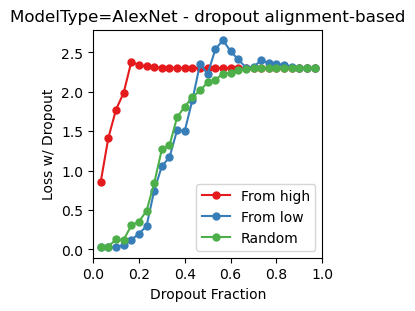

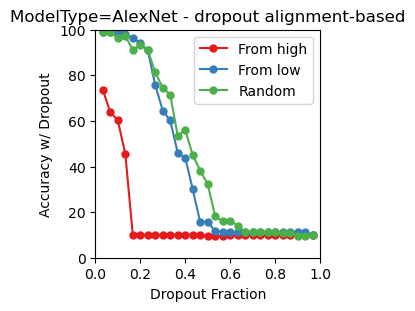

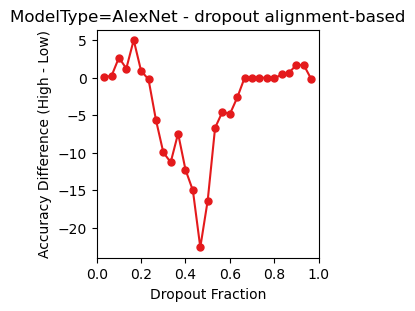

In [5]:
from alignment_v2 import plotting
from alignment.train import progressive_dropout#, progressive_dropout_train

# def progressive_dropout_experiment(exp, nets, dataset, alignment=None, train_set=False, num_drops=10, by_layer=True):
#     """
#     Perform a progressive dropout (of nodes) experiment.
#     """
#     # Targeted dropout experiment
#     print("performing targeted dropout...")
#     dropout_parameters = dict(num_drops=num_drops, by_layer=by_layer, train_set=train_set)
#     dropout_results = progressive_dropout(nets, dataset, alignment=alignment, **dropout_parameters)
#     return dropout_results, dropout_parameters

def progressive_dropout_experiment(exp, nets, dataset, alignment=None, train_set=False, num_drops=10, by_layer=True, retrain=False):

    #dropout_func = progressive_dropout_train if retrain else progressive_dropout
    dropout_func = progressive_dropout
    
    # Targeted dropout experiment
    print("Performing targeted dropout" + (" with retraining..." if retrain else "..."))
    dropout_parameters = dict(num_drops=num_drops, by_layer=by_layer, train_set=train_set)
    dropout_results = dropout_func(nets, dataset, alignment=alignment, **dropout_parameters)    
    return dropout_results, dropout_parameters


# Set parameters for the dropout experiment
num_drops = 29
by_layer = False
train_set = False
retrain = False  # Set to True to perform retraining after pruning
exp = {'args': {'num_drops': num_drops, 'dropout_by_layer': by_layer}}

# Step 2: Perform Progressive Dropout Experiment
print("Performing progressive dropout based on alignment...")
dropout_params = {
    "num_drops": num_drops,      # Number of dropout levels to apply
    "by_layer": by_layer,        # Apply dropout by each layer
    "train_set": train_set,      # Use the test set for measuring dropout effects
    "retrain": retrain           # Enable retraining if required
}

# Run the dropout experiment and retrieve the results
dropout_results, dropout_parameters = progressive_dropout_experiment(
    exp, nets, dataset, alignment=results["alignment"], **dropout_params
)

# Separate results for before and after retraining if retraining was enabled
if retrain:
    # Assuming progressive_dropout_train outputs pre- and post-training results as a tuple
    dropout_results_before = dropout_results["before"]
    dropout_results_after = dropout_results["after"]
else:
    dropout_results_before = dropout_results
    dropout_results_after = None

# Define experiment parameters for plotting
prms = {
    "vals": [model_name],
    "name": "ModelType",
    "dataset": dataset_name,
    "dropout": dropout_rate,
    "lr": learning_rate,
    "weight_decay": weight_decay
}

print("Plotting dropout experiment results...")

# Plotting both before and after retraining results
plotting.plot_dropout_results(
    exp=None,  # replace with experiment name if needed
    dropout_results=dropout_results_before,
    dropout_parameters=dropout_parameters,
    prms=prms,
    dropout_type="alignment-based",
)

if retrain:
    plotting.plot_dropout_results(
        exp=None,  # replace with experiment name if needed
        dropout_results=dropout_results_after,
        dropout_parameters=dropout_parameters,
        prms=prms,
        dropout_type="alignment-based",
    )